
# SCANIA Component X Dataset — Exploratory Data Analysis

## Objective

This notebook explores the **SCANIA Component X predictive maintenance dataset** and reproduces the main exploratory figures presented in the associated article.

The goals are to:

- understand the different data sources and files;
- inspect the operational time-series data;
- analyze missing values and temporal structure;
- study cumulative counters and histogram-based variables;
- inspect the repair target and vehicle specifications;
- reproduce key figures from the article;
- understand why these characteristics matter for predictive maintenance.

---

## Dataset overview

The dataset combines three main sources of information:

1. **Operational readouts**  
   Multivariate time-series measurements collected from trucks during operation.

2. **Repair information**  
   Information indicating whether the anonymized **Component X** was repaired during the study period.

3. **Vehicle specifications**  
   Static categorical information describing technical characteristics of each truck.

### Dataset files

#### Training set
- `train_operational_readouts.csv`
- `train_tte.csv`
- `train_specifications.csv`

#### Validation set
- `validation_operational_readouts.csv`
- `validation_labels.csv`
- `validation_specifications.csv`

#### Test set
- `test_operational_readouts.csv`
- `test_specifications.csv`

The test set does not contain the true target labels because these are intended to be predicted.

---

## Anonymization

Because the data comes from real SCANIA trucks, several anonymization mechanisms were applied:

- the studied component is referred to only as **Component X**;
- vehicle identifiers are anonymized;
- operational variables use numerical identifiers such as `171`, `397`, or `835`;
- real timestamps are replaced by relative `time_step` values;
- some operational values and repair/readout frequencies may have been perturbed or scaled.

The operational variables are organized into:

- **8 cumulative numerical counters**;
- **6 histogram variables** composed of several bins.

This mixture of temporal, cumulative, histogram-based and categorical information makes the dataset particularly relevant for predictive maintenance.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Optional dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# ============================================================
# FIND PROJECT ROOT
# ============================================================

def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "pyproject.toml").exists():
            return path

    raise FileNotFoundError(
        "Could not find the project root. "
        "Make sure the notebook is inside the project containing pyproject.toml."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder :", DATA_DIR)


# ============================================================
# LOAD TRAIN DATA
# ============================================================

df = pd.read_csv(DATA_DIR / "train_operational_readouts.csv")
tte = pd.read_csv(DATA_DIR / "train_tte.csv")
specs = pd.read_csv(DATA_DIR / "train_specifications.csv")

# Sort for all temporal analyses
df = df.sort_values(
    ["vehicle_id", "time_step"]
).reset_index(drop=True)


print("\nOperational data:", df.shape)
print("TTE data        :", tte.shape)
print("Specifications  :", specs.shape)

print("\nNumber of vehicles:", df["vehicle_id"].nunique())

display(df.head())


Project root: C:\Users\anton\Desktop\A5\HPC\Convergence\Code Convergence\hpc-case-study-2
Data folder : C:\Users\anton\Desktop\A5\HPC\Convergence\Code Convergence\hpc-case-study-2\data

Operational data: (1122452, 107)
TTE data        : (23550, 3)
Specifications  : (23550, 9)

Number of vehicles: 23550


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0



## 1. General dataset exploration

We first inspect:

- the number of observations;
- the number of variables;
- the number of unique vehicles;
- the time range;
- duplicates;
- data types;
- missing values.

Missing values are important because predictive-maintenance models are often sensitive to incomplete sensor data.


Rows: 1,122,452
Columns: 107
Vehicles: 23,550
Time step range: 0.0 → 507.4
Exact duplicated rows: 0
Duplicated vehicle_id / time_step: 0

Data types:


,dtype,number_of_columns
0,float64,106
1,int64,1



Top 20 features with the most missing values:


,feature,missing_percent
0,291_1,0.857765
1,291_3,0.857765
2,291_0,0.857765
3,291_10,0.857765
4,291_9,0.857765
5,291_8,0.857765
6,291_2,0.857765
7,291_4,0.857765
8,291_5,0.857765
9,291_7,0.857765


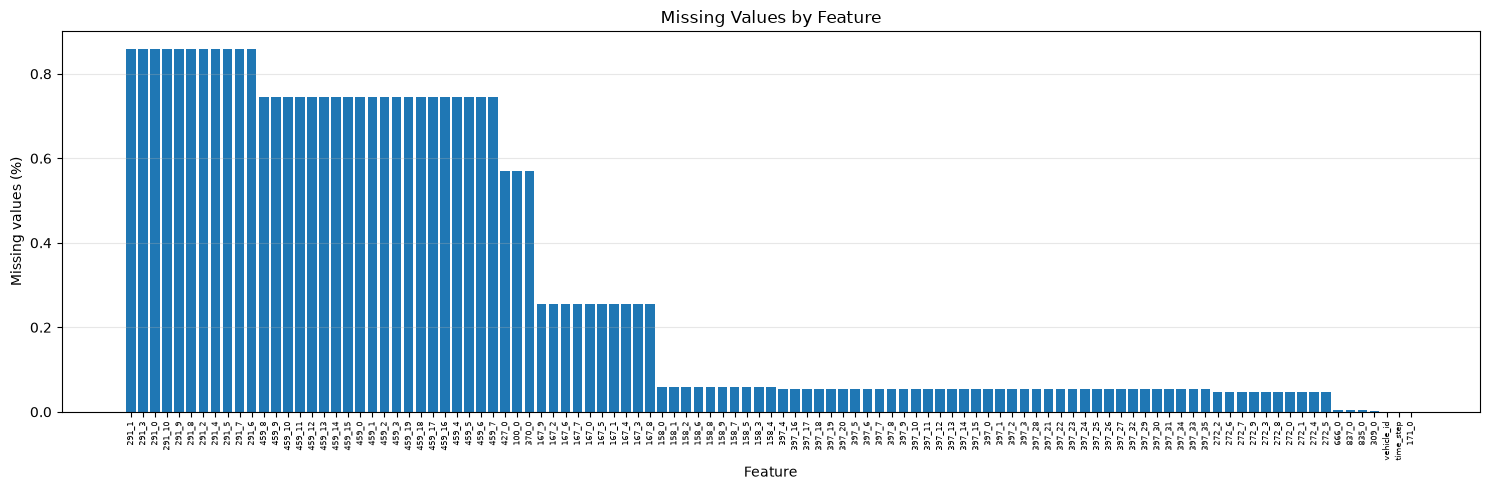

In [2]:

# ============================================================
# GENERAL OVERVIEW
# ============================================================

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])
print("Vehicles:", f"{df['vehicle_id'].nunique():,}")

print(
    "Time step range:",
    df["time_step"].min(),
    "→",
    df["time_step"].max()
)

print(
    "Exact duplicated rows:",
    df.duplicated().sum()
)

print(
    "Duplicated vehicle_id / time_step:",
    df.duplicated(
        subset=["vehicle_id", "time_step"]
    ).sum()
)


# ============================================================
# DATA TYPES
# ============================================================

dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="number_of_columns")
)

print("\nData types:")
display(dtype_summary)


# ============================================================
# MISSING VALUES
# ============================================================

missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "feature": missing.index,
    "missing_percent": missing.values
})

print("\nTop 20 features with the most missing values:")
display(missing_df.head(20))


plt.figure(figsize=(15, 5))

plt.bar(
    missing.index,
    missing.values
)

plt.xticks(
    rotation=90,
    fontsize=6
)

plt.ylabel("Missing values (%)")
plt.xlabel("Feature")
plt.title("Missing Values by Feature")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()



### Observations

The operational dataset contains repeated observations for each vehicle, which confirms that this is a **multivariate time-series problem** rather than a standard tabular dataset.

The missing-value figure should be compared with the article. The article reports only a small amount of missingness in the operational variables. If the same pattern is observed here, missing data should not represent a major obstacle, although an imputation strategy may still be required before modelling.

Duplicate `(vehicle_id, time_step)` pairs should also be checked because several observations at exactly the same vehicle/time combination could indicate duplicated data or a special collection mechanism.



## 2. Temporal structure of the vehicles

A **readout** corresponds to one recorded observation of a vehicle at a given `time_step`.

Vehicles do not necessarily have:

- the same number of readouts;
- the same observation duration;
- the same sampling frequency.

This irregular temporal structure is important because predictive-maintenance models must often work with vehicles having very different amounts of historical information.


Vehicle statistics:


,n_readouts,observation_duration
count,23550.000000,23550.000000
mean,47.662505,227.210692
std,27.406028,89.700115
min,5.000000,11.200000
25%,28.000000,150.200000
50%,43.000000,208.400000
75%,64.000000,296.950000
max,303.000000,504.200000



Sampling interval statistics:


count    1.098902e+06
mean     4.869235e+00
std      5.133735e+00
min      2.000000e-01
25%      1.600000e+00
50%      4.400000e+00
75%      6.200000e+00
max      3.878000e+02
Name: time_step, dtype: float64

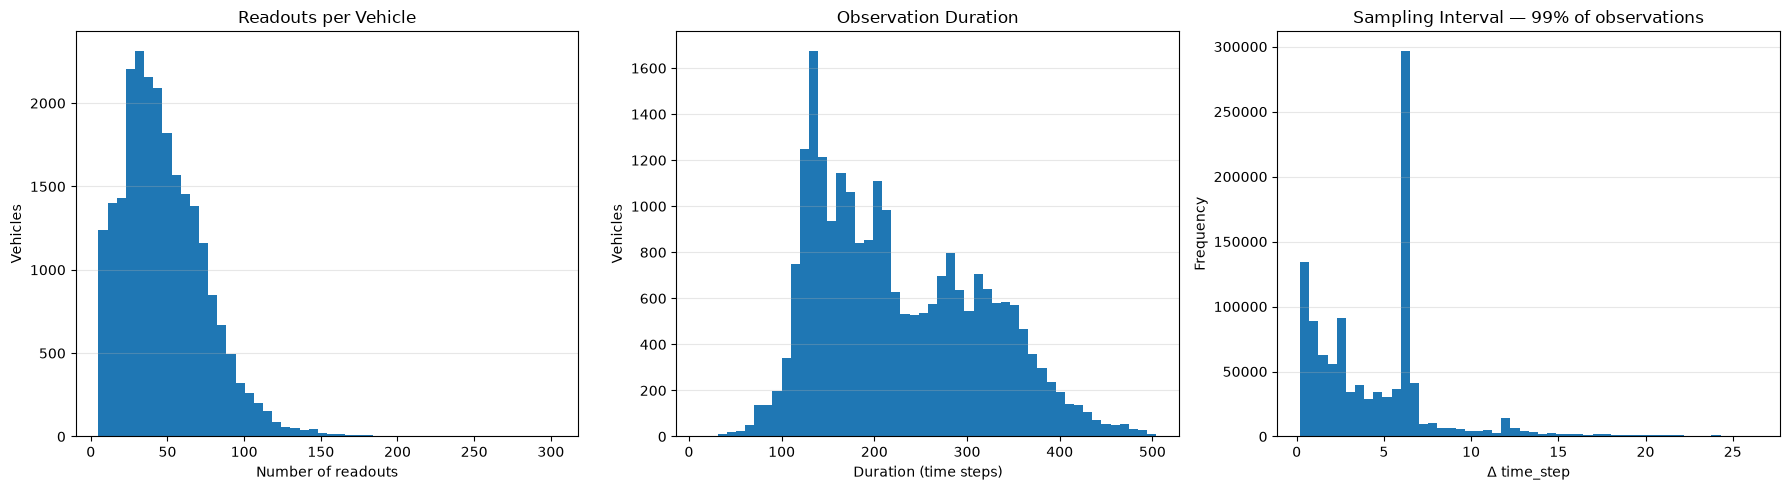

In [3]:

# ============================================================
# VEHICLE-LEVEL TEMPORAL STATISTICS
# ============================================================

vehicle_stats = (
    df.groupby("vehicle_id")
    .agg(
        n_readouts=("time_step", "size"),
        first_time=("time_step", "min"),
        last_time=("time_step", "max")
    )
    .reset_index()
)

vehicle_stats["observation_duration"] = (
    vehicle_stats["last_time"]
    - vehicle_stats["first_time"]
)


# Interval between consecutive measurements
delta_time = (
    df.groupby("vehicle_id")["time_step"]
    .diff()
)

valid_delta_time = delta_time[
    delta_time > 0
].dropna()


print("Vehicle statistics:")
display(
    vehicle_stats[
        ["n_readouts", "observation_duration"]
    ].describe()
)

print("\nSampling interval statistics:")
display(valid_delta_time.describe())


# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# Number of readouts
axes[0].hist(
    vehicle_stats["n_readouts"],
    bins=50
)

axes[0].set_title("Readouts per Vehicle")
axes[0].set_xlabel("Number of readouts")
axes[0].set_ylabel("Vehicles")


# Observation duration
axes[1].hist(
    vehicle_stats["observation_duration"],
    bins=50
)

axes[1].set_title("Observation Duration")
axes[1].set_xlabel("Duration (time steps)")
axes[1].set_ylabel("Vehicles")


# Sampling interval
upper_limit = valid_delta_time.quantile(0.99)

axes[2].hist(
    valid_delta_time[
        valid_delta_time <= upper_limit
    ],
    bins=50
)

axes[2].set_title("Sampling Interval — 99% of observations")
axes[2].set_xlabel("Δ time_step")
axes[2].set_ylabel("Frequency")


for ax in axes:
    ax.grid(
        axis="y",
        alpha=0.3
    )

plt.tight_layout()
plt.show()



### Observations

The three distributions above help answer three different questions:

- **Readouts per vehicle:** how much historical information is available for each truck?
- **Observation duration:** for how long is each truck observed?
- **Sampling interval:** are observations collected regularly or irregularly?

Strong variability between vehicles means that the future modelling pipeline must be robust to different sequence lengths and irregular observation histories.



## 3. Cumulative numerical counters

The dataset contains eight cumulative counters:

`171_0`, `666_0`, `427_0`, `837_0`, `309_0`, `835_0`, `370_0`, `100_0`.

Because they are cumulative, their values generally increase over time.

We reproduce several analyses inspired by the article:

1. evolution of counters over time for one vehicle;
2. correlation between raw counter values;
3. correlation between counter increments;
4. percentage of negative increments, which can indicate possible counter resets or inconsistencies.

Raw cumulative counters may be highly correlated simply because they all increase with vehicle usage. Looking at **increments** helps distinguish this common temporal trend from more meaningful relationships.


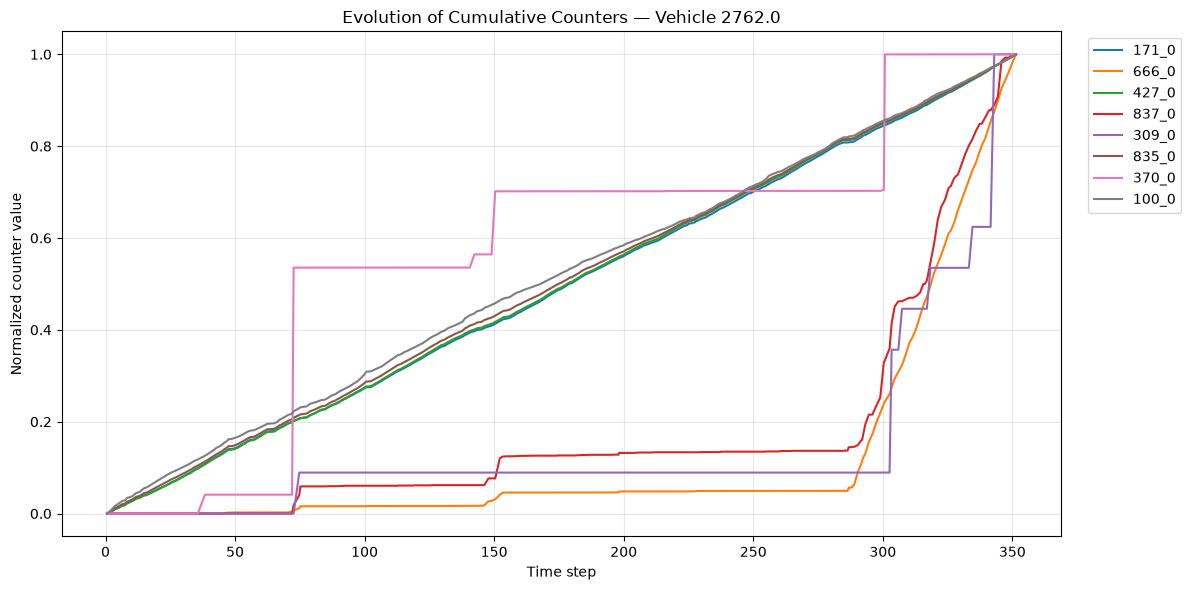

Potential resets / negative increments:


,negative_delta_percent
171_0,0.000624
666_0,0.000000
427_0,0.000000
837_0,0.000000
309_0,0.000000
835_0,0.000000
370_0,0.000000
100_0,0.000000


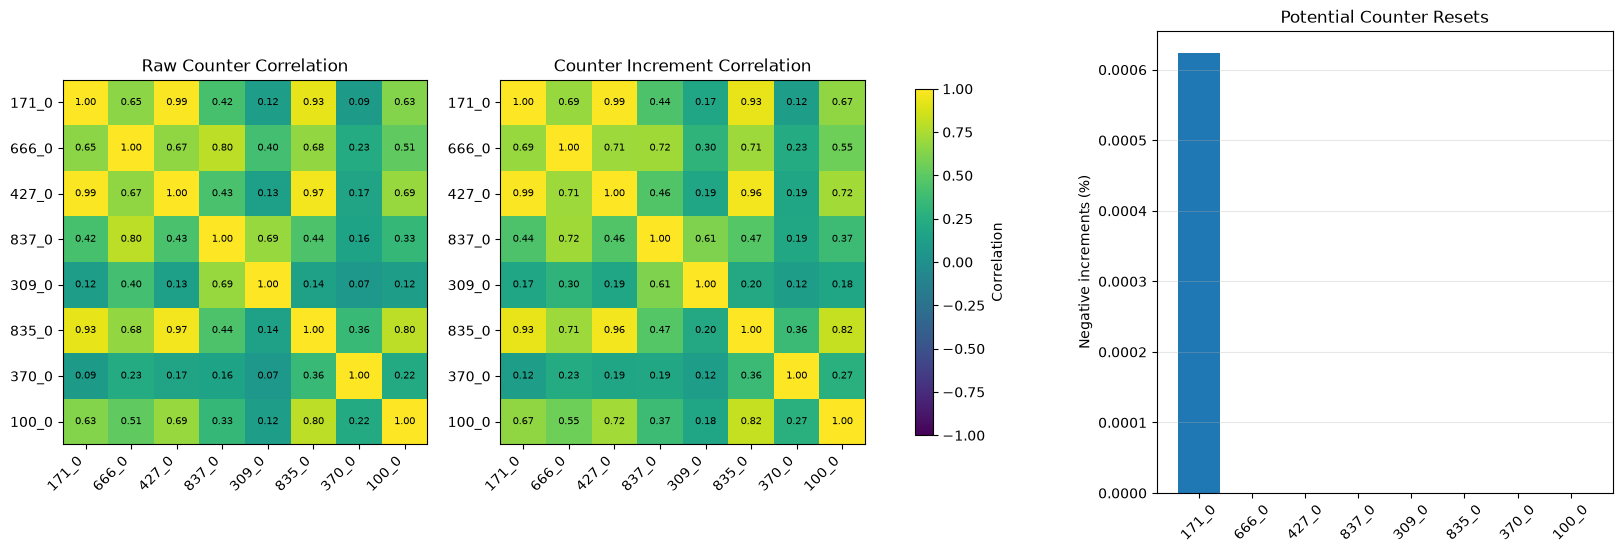

In [4]:

COUNTERS = [
    "171_0",
    "666_0",
    "427_0",
    "837_0",
    "309_0",
    "835_0",
    "370_0",
    "100_0",
]


# ============================================================
# EXAMPLE VEHICLE
# ============================================================

example_vehicle = (
    vehicle_stats
    .sort_values("n_readouts", ascending=False)
    .iloc[0]["vehicle_id"]
)

vehicle_df = df[
    df["vehicle_id"] == example_vehicle
].copy()


plt.figure(figsize=(12, 6))

for feature in COUNTERS:

    values = vehicle_df[feature]

    if values.max() > values.min():
        normalized = (
            values - values.min()
        ) / (
            values.max() - values.min()
        )

        plt.plot(
            vehicle_df["time_step"],
            normalized,
            label=feature
        )

plt.xlabel("Time step")
plt.ylabel("Normalized counter value")

plt.title(
    f"Evolution of Cumulative Counters — Vehicle {example_vehicle}"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# COUNTER INCREMENTS
# ============================================================

counter_deltas = (
    df.groupby("vehicle_id")[COUNTERS]
    .diff()
)

raw_corr = df[COUNTERS].corr()
delta_corr = counter_deltas.corr()

reset_percent = (
    counter_deltas
    .lt(0)
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Potential resets / negative increments:")
display(
    reset_percent
    .rename("negative_delta_percent")
    .to_frame()
)


# ============================================================
# CORRELATION PLOT FUNCTION
# ============================================================

def plot_corr(ax, corr, title):

    im = ax.imshow(
        corr,
        vmin=-1,
        vmax=1
    )

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))

    ax.set_xticklabels(
        corr.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        corr.index
    )

    for i in range(len(corr)):
        for j in range(len(corr.columns)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

    ax.set_title(title)

    return im


# ============================================================
# CORRELATIONS + RESETS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

im = plot_corr(
    axes[0],
    raw_corr,
    "Raw Counter Correlation"
)

plot_corr(
    axes[1],
    delta_corr,
    "Counter Increment Correlation"
)

axes[2].bar(
    reset_percent.index,
    reset_percent.values
)

axes[2].set_title(
    "Potential Counter Resets"
)

axes[2].set_ylabel(
    "Negative increments (%)"
)

axes[2].tick_params(
    axis="x",
    rotation=45
)

axes[2].grid(
    axis="y",
    alpha=0.3
)

fig.colorbar(
    im,
    ax=axes[:2],
    shrink=0.75,
    label="Correlation"
)

plt.show()



### Observations

The cumulative counters are expected to show strong positive trends over time.

A high correlation between **raw cumulative counters** does not necessarily mean that two variables represent the same physical phenomenon. It may simply occur because both counters increase as the vehicle is used.

For this reason, the correlation between **counter increments** is often more informative.

Negative increments are also worth investigating. Since these variables are cumulative, negative differences can reveal counter resets, data corrections or collection inconsistencies. Such resets are particularly important in predictive maintenance because they can create artificial discontinuities in a vehicle's history.



## 4. Histogram variables

Six anonymized operational variables are represented as histograms:

| Variable | Number of bins |
|---|---:|
| 167 | 10 |
| 272 | 10 |
| 291 | 11 |
| 158 | 10 |
| 459 | 20 |
| 397 | 36 |

Each bin represents an anonymized operating condition.

For example, instead of storing a single measurement, a histogram variable can describe how much vehicle usage occurred under different conditions.

We first reproduce a figure similar to the article using variables **167** and **459** for one vehicle, then visualize the average normalized profile of all six histogram variables at the last readout of each vehicle.


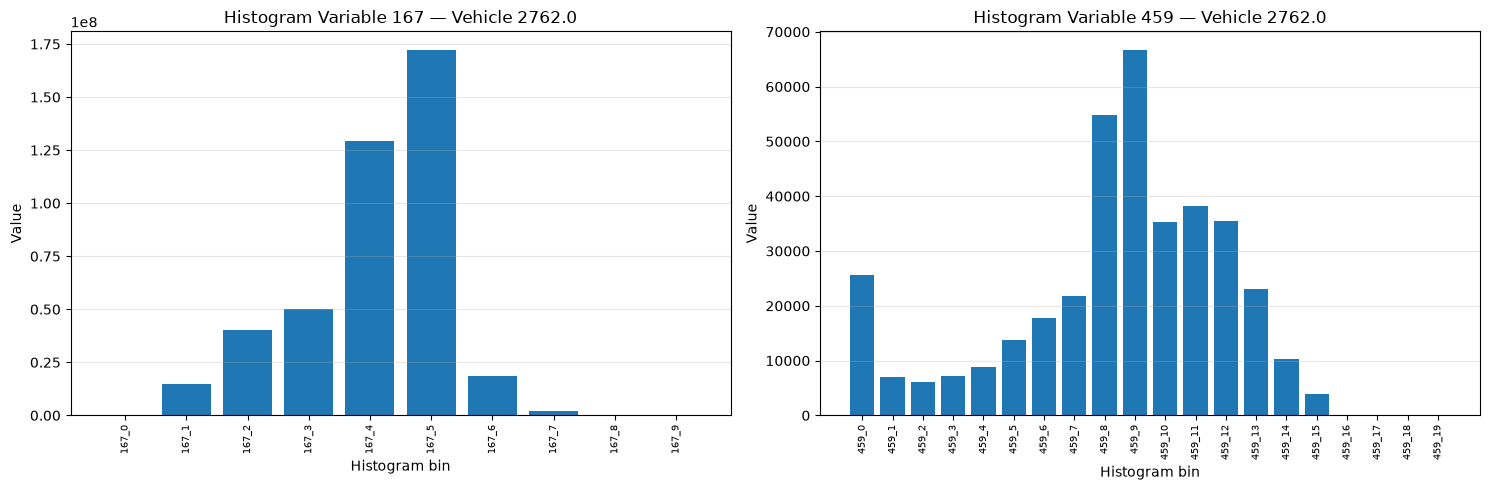

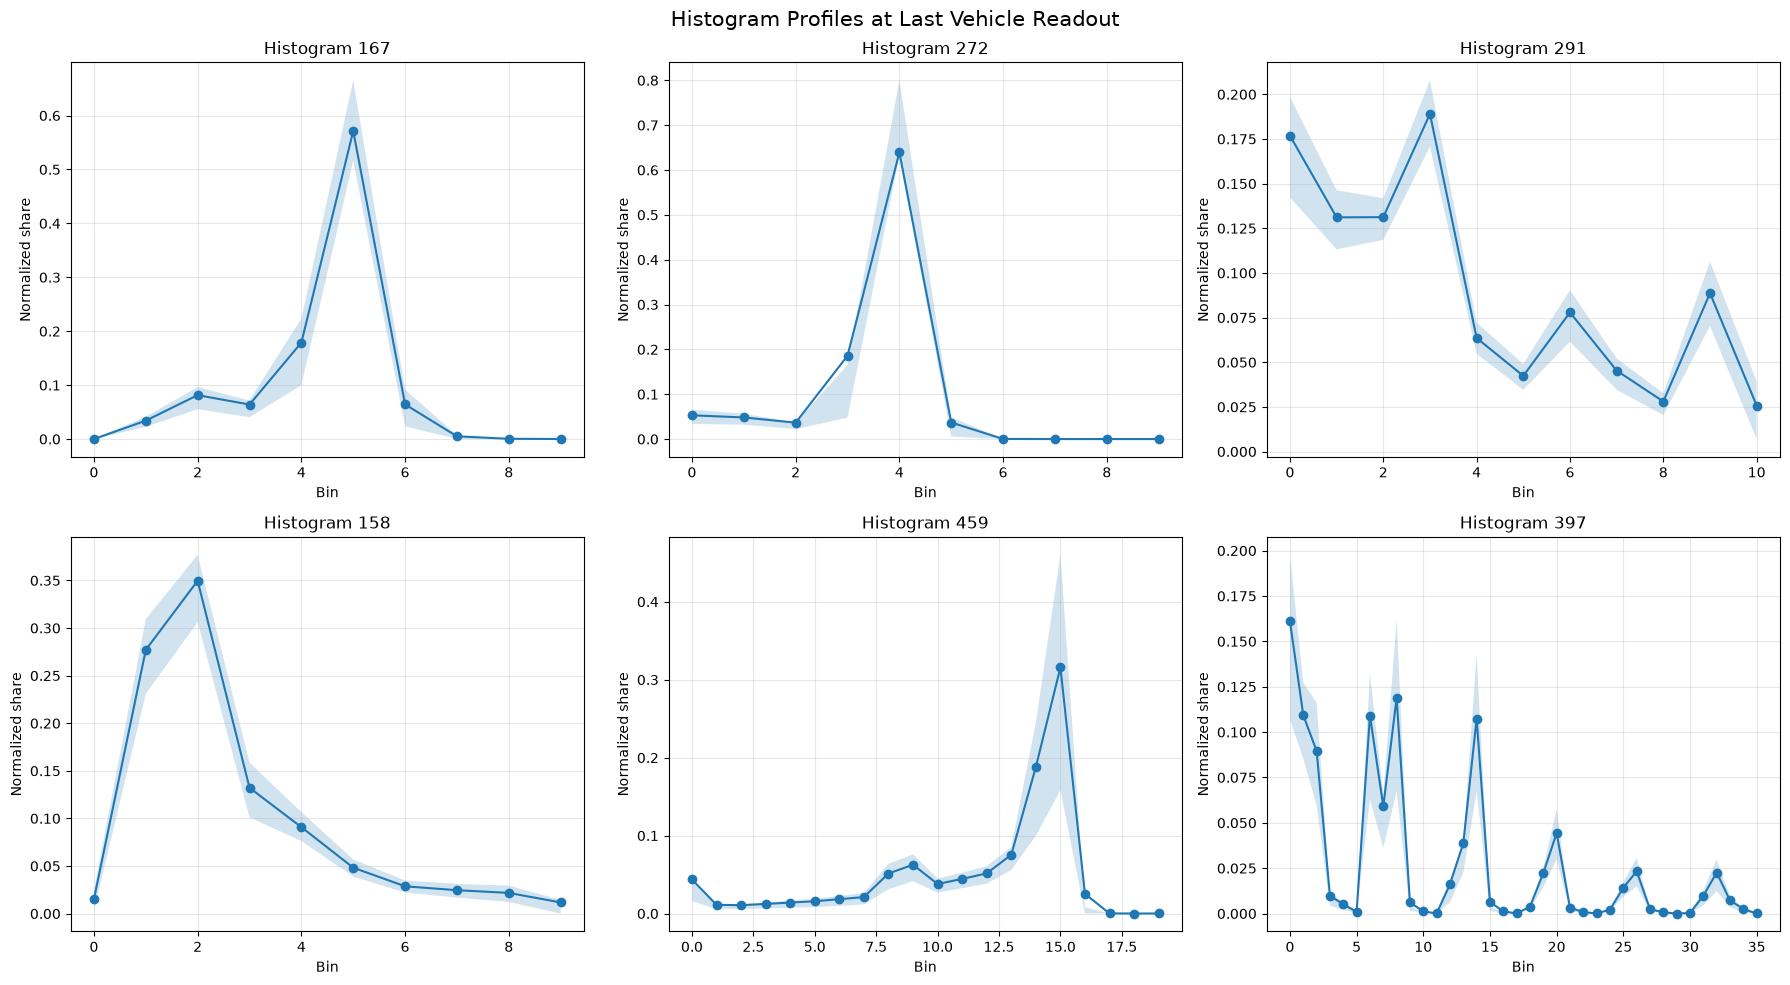

In [5]:

HISTOGRAM_PREFIXES = [
    "167",
    "272",
    "291",
    "158",
    "459",
    "397",
]


def get_histogram_columns(dataframe, prefix):

    columns = [
        col
        for col in dataframe.columns
        if col.startswith(prefix + "_")
    ]

    return sorted(
        columns,
        key=lambda x: int(x.split("_")[1])
    )


# ============================================================
# LAST READOUT OF EACH VEHICLE
# ============================================================

last_readouts = (
    df.groupby("vehicle_id")
    .tail(1)
    .copy()
)


# ============================================================
# ARTICLE-LIKE EXAMPLE: VARIABLES 167 AND 459
# ============================================================

example_last = (
    vehicle_df
    .sort_values("time_step")
    .iloc[-1]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

for ax, prefix in zip(axes, ["167", "459"]):

    columns = get_histogram_columns(
        df,
        prefix
    )

    values = (
        example_last[columns]
        .astype(float)
        .values
    )

    ax.bar(
        range(len(columns)),
        values
    )

    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(
        columns,
        rotation=90,
        fontsize=7
    )

    ax.set_title(
        f"Histogram Variable {prefix} — Vehicle {example_vehicle}"
    )

    ax.set_xlabel("Histogram bin")
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# AVERAGE NORMALIZED HISTOGRAM PROFILES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()


for ax, prefix in zip(
    axes,
    HISTOGRAM_PREFIXES
):

    columns = get_histogram_columns(
        df,
        prefix
    )

    values = (
        last_readouts[columns]
        .astype(float)
        .to_numpy()
    )

    totals = np.nansum(
        values,
        axis=1,
        keepdims=True
    )

    normalized = np.divide(
        values,
        totals,
        out=np.full_like(
            values,
            np.nan,
            dtype=float
        ),
        where=totals != 0
    )

    mean_profile = np.nanmean(
        normalized,
        axis=0
    )

    q25 = np.nanpercentile(
        normalized,
        25,
        axis=0
    )

    q75 = np.nanpercentile(
        normalized,
        75,
        axis=0
    )

    x = np.arange(
        len(columns)
    )

    ax.plot(
        x,
        mean_profile,
        marker="o"
    )

    ax.fill_between(
        x,
        q25,
        q75,
        alpha=0.2
    )

    ax.set_title(
        f"Histogram {prefix}"
    )

    ax.set_xlabel("Bin")
    ax.set_ylabel("Normalized share")

    ax.grid(
        alpha=0.3
    )


plt.suptitle(
    "Histogram Profiles at Last Vehicle Readout",
    fontsize=15
)

plt.tight_layout()
plt.show()



### Observations

Histogram features encode **how vehicle activity is distributed across operating conditions**.

A dominant bin means that a large share of the accumulated activity occurred in the corresponding condition.

Comparing histogram profiles between vehicles can therefore reveal different usage patterns even when the total accumulated usage is similar.

The normalized profiles are useful because vehicles may have very different absolute activity levels. Normalization focuses the analysis on the **shape of the operating profile** rather than its total magnitude.



## 5. Repair target and vehicle specifications

The training target `in_study_repair` indicates whether Component X was repaired during the observation period.

Predictive-maintenance datasets are often highly imbalanced because failures are much rarer than normal operation. This is important because a model that always predicts the majority class can obtain deceptively high accuracy while being practically useless.

The vehicle specifications are static categorical variables such as anonymized engine or configuration information. Their distributions can reveal whether certain vehicle configurations are much more common than others.


Target distribution:


,count,percentage
in_study_repair,,
0,21278,90.352442
1,2272,9.647558



Study duration by target:


,count,mean,std,min,25%,50%,75%,max
in_study_repair,,,,,,,,
0,21278.0,243.161726,89.184566,121.0,165.20,219.0,316.40,510.0
1,2272.0,214.007130,80.293009,73.4,148.55,208.4,276.25,482.0


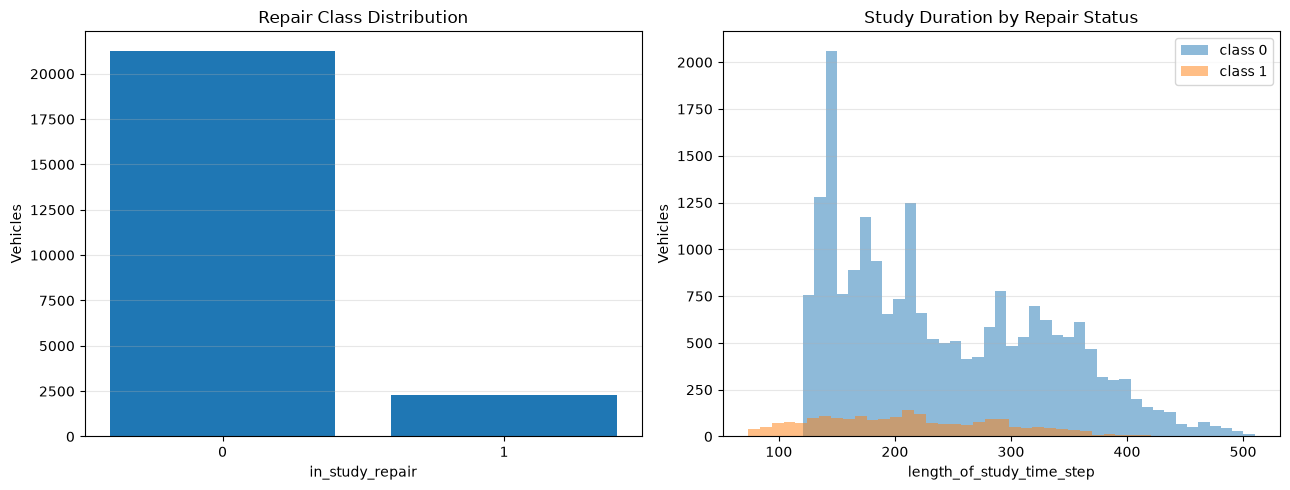

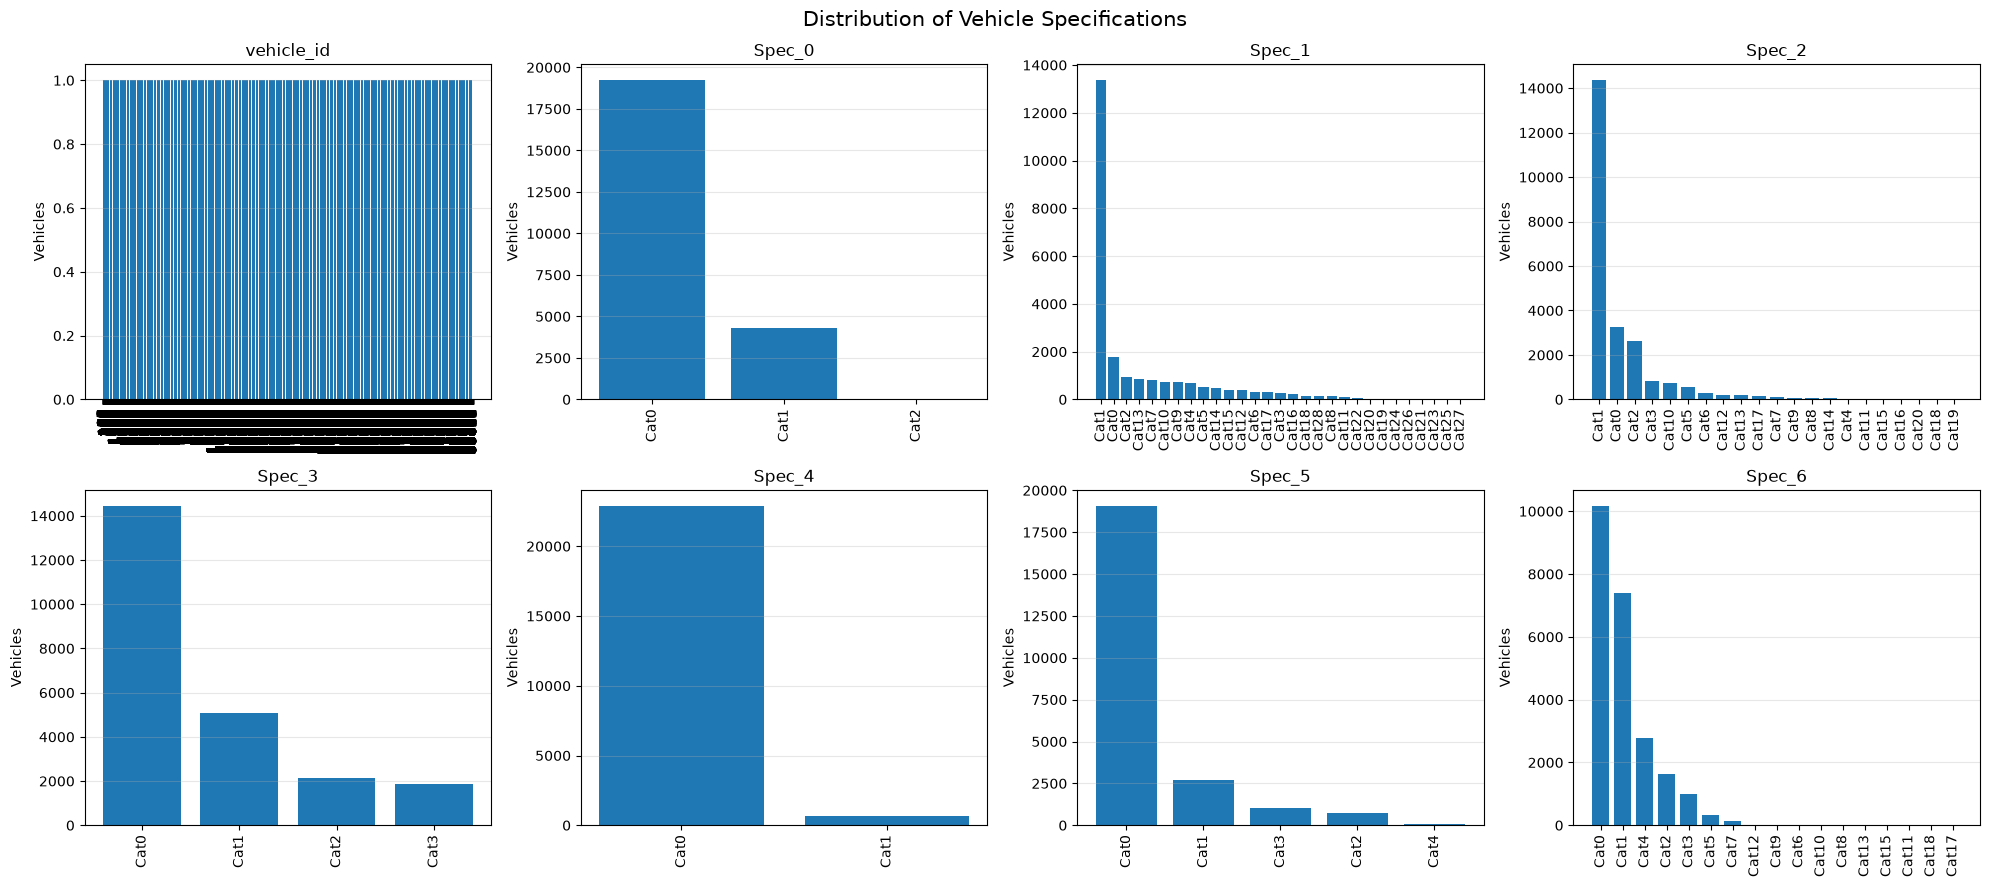

In [6]:

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_counts = (
    tte["in_study_repair"]
    .value_counts()
    .sort_index()
)

target_percent = (
    tte["in_study_repair"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

print("Target distribution:")
display(target_summary)


print("\nStudy duration by target:")
display(
    tte.groupby(
        "in_study_repair"
    )["length_of_study_time_step"]
    .describe()
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].bar(
    target_counts.index.astype(str),
    target_counts.values
)

axes[0].set_title(
    "Repair Class Distribution"
)

axes[0].set_xlabel(
    "in_study_repair"
)

axes[0].set_ylabel(
    "Vehicles"
)


for label in sorted(
    tte["in_study_repair"].unique()
):

    values = tte.loc[
        tte["in_study_repair"] == label,
        "length_of_study_time_step"
    ]

    axes[1].hist(
        values,
        bins=40,
        alpha=0.5,
        label=f"class {label}"
    )


axes[1].set_title(
    "Study Duration by Repair Status"
)

axes[1].set_xlabel(
    "length_of_study_time_step"
)

axes[1].set_ylabel(
    "Vehicles"
)

axes[1].legend()


for ax in axes:
    ax.grid(
        axis="y",
        alpha=0.3
    )

plt.tight_layout()
plt.show()


# ============================================================
# VEHICLE SPECIFICATIONS
# ============================================================

spec_columns = list(
    specs.columns
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20, 9)
)

axes = axes.flatten()


for ax, column in zip(
    axes,
    spec_columns
):

    counts = (
        specs[column]
        .value_counts()
        .sort_values(ascending=False)
    )

    ax.bar(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(column)

    ax.tick_params(
        axis="x",
        rotation=90
    )

    ax.set_ylabel(
        "Vehicles"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )


plt.suptitle(
    "Distribution of Vehicle Specifications",
    fontsize=15
)

plt.tight_layout()
plt.show()



### Observations

The class distribution should be interpreted carefully.

If the repair class is much less frequent than the healthy class, the dataset is **imbalanced**. In that case:

- accuracy alone is not an appropriate evaluation metric;
- recall for failure cases becomes important;
- class weighting, resampling or cost-sensitive learning may be useful;
- false negatives may be much more costly than false positives in a maintenance context.

The specification plots also show whether some vehicle configurations dominate the fleet. These variables may later help explain differences in degradation patterns between groups of vehicles.



## 6. Validation-set class distribution and dimensionality reduction

The article also visualizes the validation set using **PCA** and **t-SNE**.

For each validation vehicle, only the **last available readout** is used. The resulting high-dimensional feature vector is projected into two dimensions.

The objective is not to build a predictive model here, but to check whether the classes form naturally separated groups in the operational feature space.

> **Note:** t-SNE can take some time to run. The code below uses all validation vehicles when possible.


Validation vehicles: 5046

Validation class distribution:


,count
class_label,
0,4910
1,16
2,14
3,30
4,76


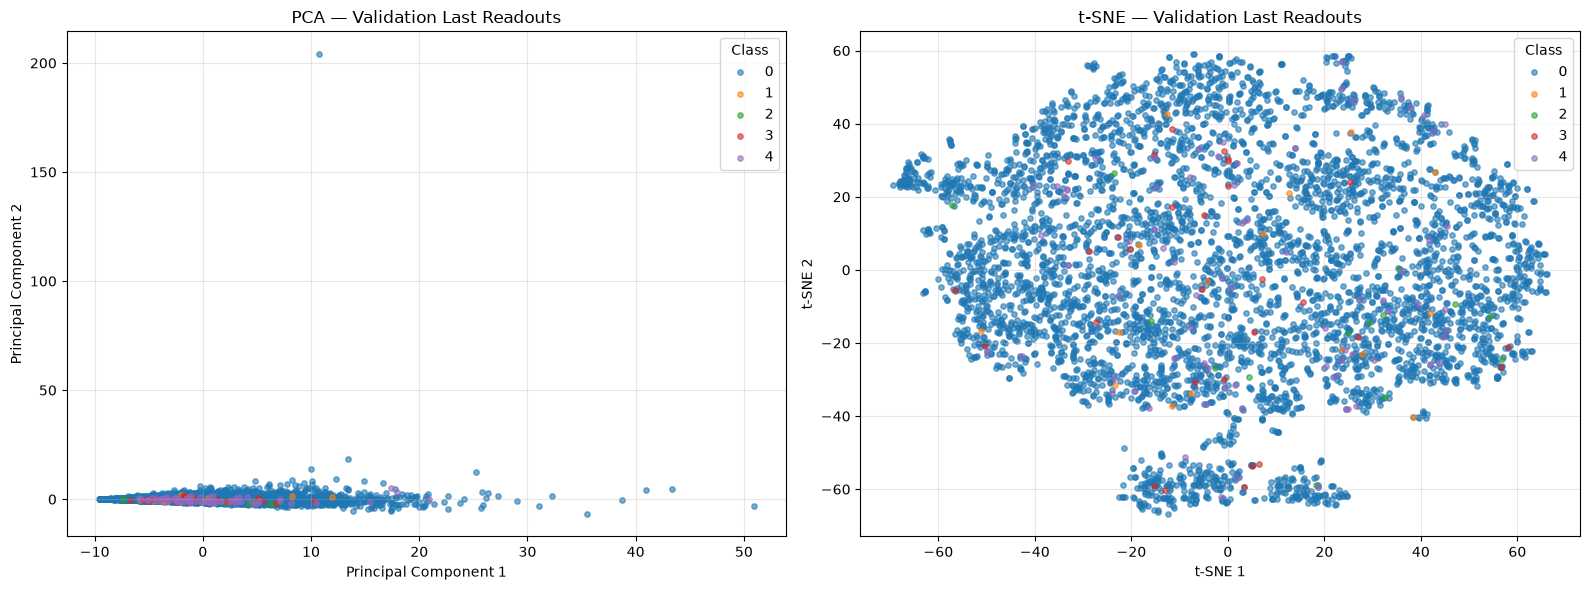

In [7]:

# ============================================================
# LOAD VALIDATION DATA
# ============================================================

validation_readouts = pd.read_csv(
    DATA_DIR / "validation_operational_readouts.csv"
)

validation_labels = pd.read_csv(
    DATA_DIR / "validation_labels.csv"
)

validation_readouts = validation_readouts.sort_values(
    ["vehicle_id", "time_step"]
).reset_index(drop=True)


# Last available readout for each vehicle
validation_last = (
    validation_readouts
    .groupby("vehicle_id")
    .tail(1)
    .reset_index(drop=True)
)


# ============================================================
# MATCH LABELS TO VEHICLES
# ============================================================

# In this dataset the label file corresponds to the validation vehicles.
# If vehicle_id is available in the label file, merge explicitly.
if "vehicle_id" in validation_labels.columns:

    validation_model_df = validation_last.merge(
        validation_labels,
        on="vehicle_id",
        how="inner"
    )

else:

    # Otherwise preserve vehicle order after sorting.
    validation_model_df = validation_last.copy()

    if len(validation_model_df) != len(validation_labels):
        raise ValueError(
            "Validation labels and validation vehicles do not have the same length."
        )

    validation_model_df["class_label"] = (
        validation_labels["class_label"].to_numpy()
    )


print("Validation vehicles:", len(validation_model_df))

print("\nValidation class distribution:")
display(
    validation_model_df["class_label"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)


# ============================================================
# PREPARE FEATURES
# ============================================================

feature_columns = [
    c
    for c in validation_model_df.columns
    if c not in ["vehicle_id", "time_step", "class_label"]
]

X = validation_model_df[feature_columns].copy()

# Median imputation
X = X.fillna(
    X.median(numeric_only=True)
)

# Replace any remaining non-numeric / problematic values if necessary
X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = validation_model_df["class_label"].to_numpy()


# ============================================================
# PCA
# ============================================================

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# t-SNE
# ============================================================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(
    X_scaled
)


# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

for label in sorted(np.unique(y)):

    mask = y == label

    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=0.6,
        label=str(label)
    )

    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=15,
        alpha=0.6,
        label=str(label)
    )


axes[0].set_title("PCA — Validation Last Readouts")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].set_title("t-SNE — Validation Last Readouts")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

for ax in axes:
    ax.legend(title="Class")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Observations

PCA and t-SNE provide a two-dimensional representation of the high-dimensional operational data.

If the different classes strongly overlap, this suggests that failure proximity cannot be identified through a simple linear or visually obvious separation of the raw last-readout features.

This reinforces the difficulty of the predictive-maintenance problem:

- degradation may depend on combinations of many variables;
- temporal history may contain information that a single last readout cannot capture;
- the severe class imbalance makes rare failure states particularly difficult to identify.



# Conclusion

This exploratory analysis highlights several important characteristics of the SCANIA Component X dataset.

First, the dataset is a large **multivariate time-series dataset** containing repeated operational measurements for thousands of vehicles. Vehicles can have different numbers of observations, different observation durations and irregular sampling intervals. These aspects must be considered when designing predictive-maintenance models.

The operational variables have two main structures:

- **cumulative numerical counters**, which capture quantities accumulated over time;
- **histogram-based variables**, which describe how vehicle activity is distributed across anonymized operating conditions.

The cumulative counters show strong temporal trends and may therefore be highly correlated in their raw form. Studying their increments provides complementary information and also helps identify potential counter resets or inconsistencies.

The dataset contains relatively few missing values, but the temporal structure, heterogeneous feature types and possible counter resets still require careful preprocessing.

The repair target is strongly imbalanced, which is typical of predictive-maintenance applications: failures are rare compared with normal operation. Consequently, future models should not be evaluated using accuracy alone, and the practical cost of false negatives must be considered.

Finally, the PCA and t-SNE visualizations illustrate that the failure-related classes are not trivially separable from the last operational readout alone.

Overall, this dataset combines:

- **multivariate time series**;
- **heterogeneous feature representations**;
- **irregular observation histories**;
- **strong class imbalance**;
- **real-world data-quality constraints**.

These characteristics make it a realistic and challenging predictive-maintenance problem.
